In [1]:
from pylib.preamble import *
enable_autoreload()

from pylib.fig_setup import PALETTE, STYLE, LW, style_ax, legend, country_handles

In [2]:
from IPython.utils.capture import capture_output
with capture_output():
    get_ipython().run_line_magic('run', '2_total_use.ipynb')

In [3]:
df_a = pd.read_parquet("0_intermediate/df_a.parquet")
df_m = pd.read_parquet("0_intermediate/df_m.parquet")

COUNTRIES = var_groups.countries

# Elektrificeringsrater

*Deskriptiv analyse af elektrificeringsraten — aggregat og overordnede sektorer over tid, samt alle delsektorer for udvalgte lande.*

*`1. aggregeret rate over tid`*

*Plotter elektrificeringsraten over tid, absolut niveau, for alle lande i analysen.*

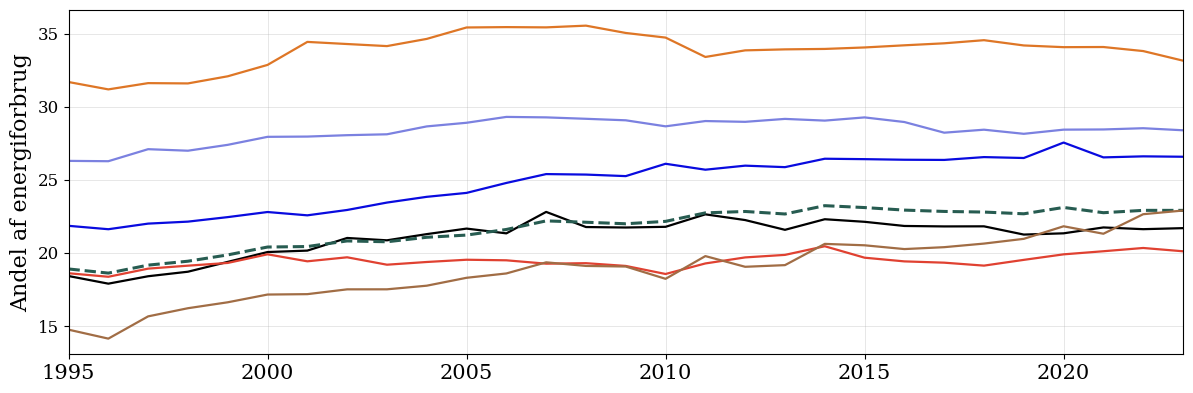

In [4]:
# 1. aggregeret rate over tid
fig, ax = plt.subplots(figsize=(12, 4))

for geo, grp in df_a.groupby("geo"):
    grp = grp.sort_values("year")
    ax.plot(grp["year"], grp["value"],
            ls=STYLE[geo], color=PALETTE[geo], lw=LW[geo], label=geo)

style_ax(ax, df_a["year"])
ax.set_ylabel("Andel af energiforbrug")
plt.tight_layout()
plt.show()

*`2. sektorrater over tid`*

*Plotter elektrificeringsraten over tid pr. overordnet sektor (industri, transport, øvrige) i 2×2-grid.*

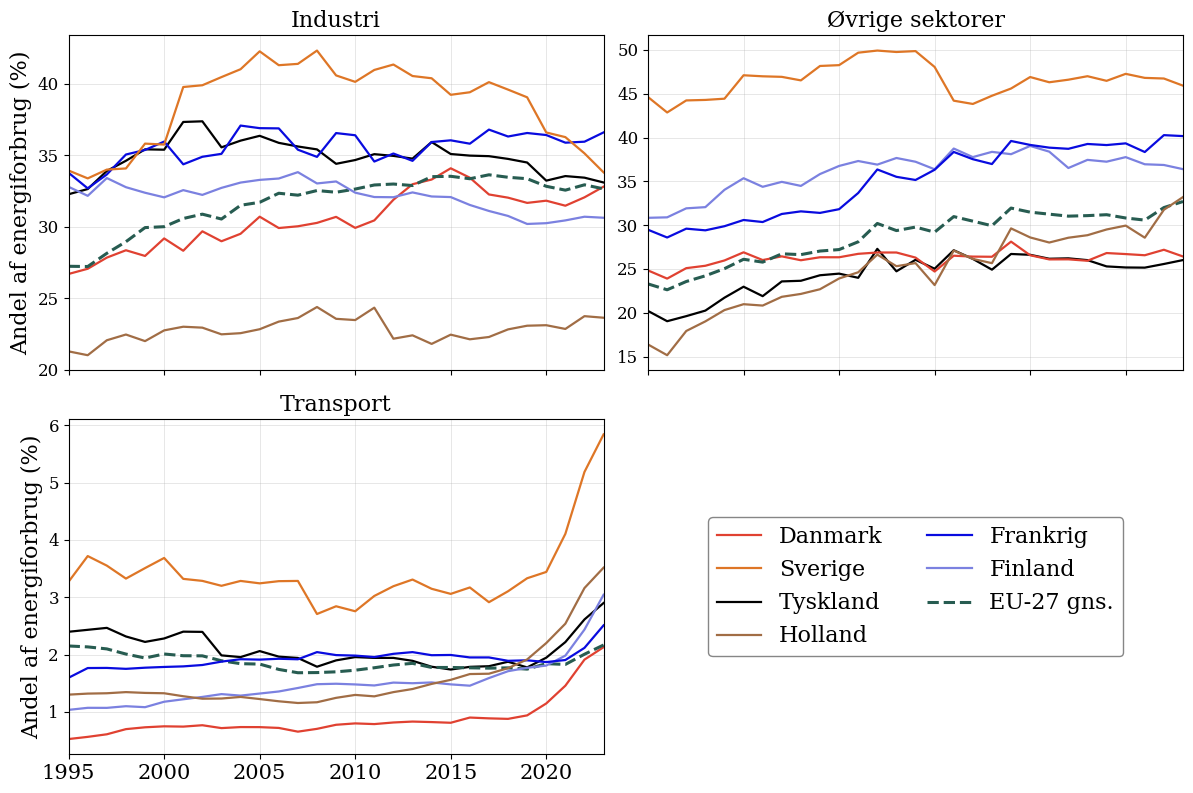

In [5]:
# 2. sektorrater over tid
parents = list(df_m["nrg_bal"].unique())
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
plot_axes = [axes[0, 0], axes[0, 1], axes[1, 0]]

for ax, nrg in zip(plot_axes, parents):
    sub = df_m[df_m["nrg_bal"] == nrg]
    for geo, grp in sub.groupby("geo"):
        grp = grp.sort_values("year").copy()
        grp.loc[(grp["value"] <= 0) | (grp["value"] > 95), "value"] = np.nan
        ax.plot(grp["year"], grp["value"],
                ls=STYLE[geo], color=PALETTE[geo], lw=LW[geo])
    style_ax(ax, sub["year"])
    ax.set_title(var_groups.labels[nrg])

axes[0, 0].set_ylabel("Andel af energiforbrug (%)")
axes[1, 0].set_ylabel("Andel af energiforbrug (%)")

ax_leg = axes[1, 1]
ax_leg.axis("off")
ax_leg.legend(handles=country_handles(COUNTRIES), loc="center",
              frameon=True, framealpha=0.95, edgecolor="0.5", fancybox=True,
              ncol=2)

plt.tight_layout()
plt.show()

*`3. samlet figur`*

*Kombinerer aggregatpanel og de tre sektorpaneler i én 2×2-figur med fælles legend.*

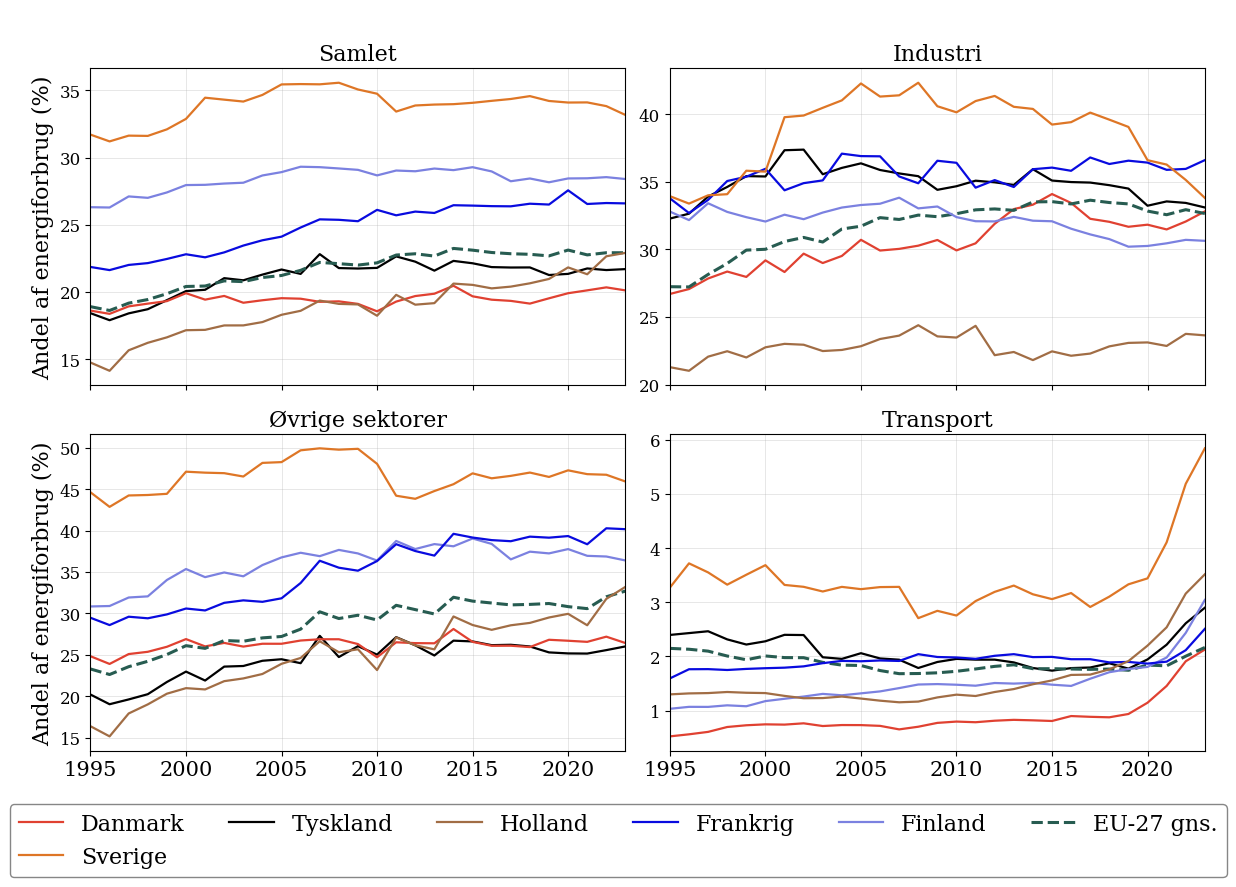

In [7]:
# 3. samlet figur
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
plot_axes = [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]]

ax = plot_axes[0]
for geo, grp in df_a.groupby("geo"):
    grp = grp.sort_values("year")
    ax.plot(grp["year"], grp["value"],
            ls=STYLE[geo], color=PALETTE[geo], lw=LW[geo])
style_ax(ax, df_a["year"])
ax.set_ylabel("Andel af energiforbrug (%)")
ax.set_title("Samlet")

parents = list(df_m["nrg_bal"].unique())
for ax, nrg in zip(plot_axes[1:], parents):
    sub = df_m[df_m["nrg_bal"] == nrg]
    for geo, grp in sub.groupby("geo"):
        grp = grp.sort_values("year").copy()
        grp.loc[(grp["value"] <= 0) | (grp["value"] > 95), "value"] = np.nan
        ax.plot(grp["year"], grp["value"],
                ls=STYLE[geo], color=PALETTE[geo], lw=LW[geo])
    style_ax(ax, sub["year"])
    ax.set_title(var_groups.labels[nrg])

axes[1, 0].set_ylabel("Andel af energiforbrug (%)")

fig.legend(handles=country_handles(COUNTRIES), loc="upper center",
           bbox_to_anchor=(0.5, 0), ncol=6,
           frameon=True, framealpha=0.95, edgecolor="0.5", fancybox=True)

plt.suptitle(' ')
plt.tight_layout()
plt.show()

*`4. delsektorrate`*

*Plotter elektrificeringsraten for alle inkluderede delsektorer i 4-kolonne-grid, alle lande.*

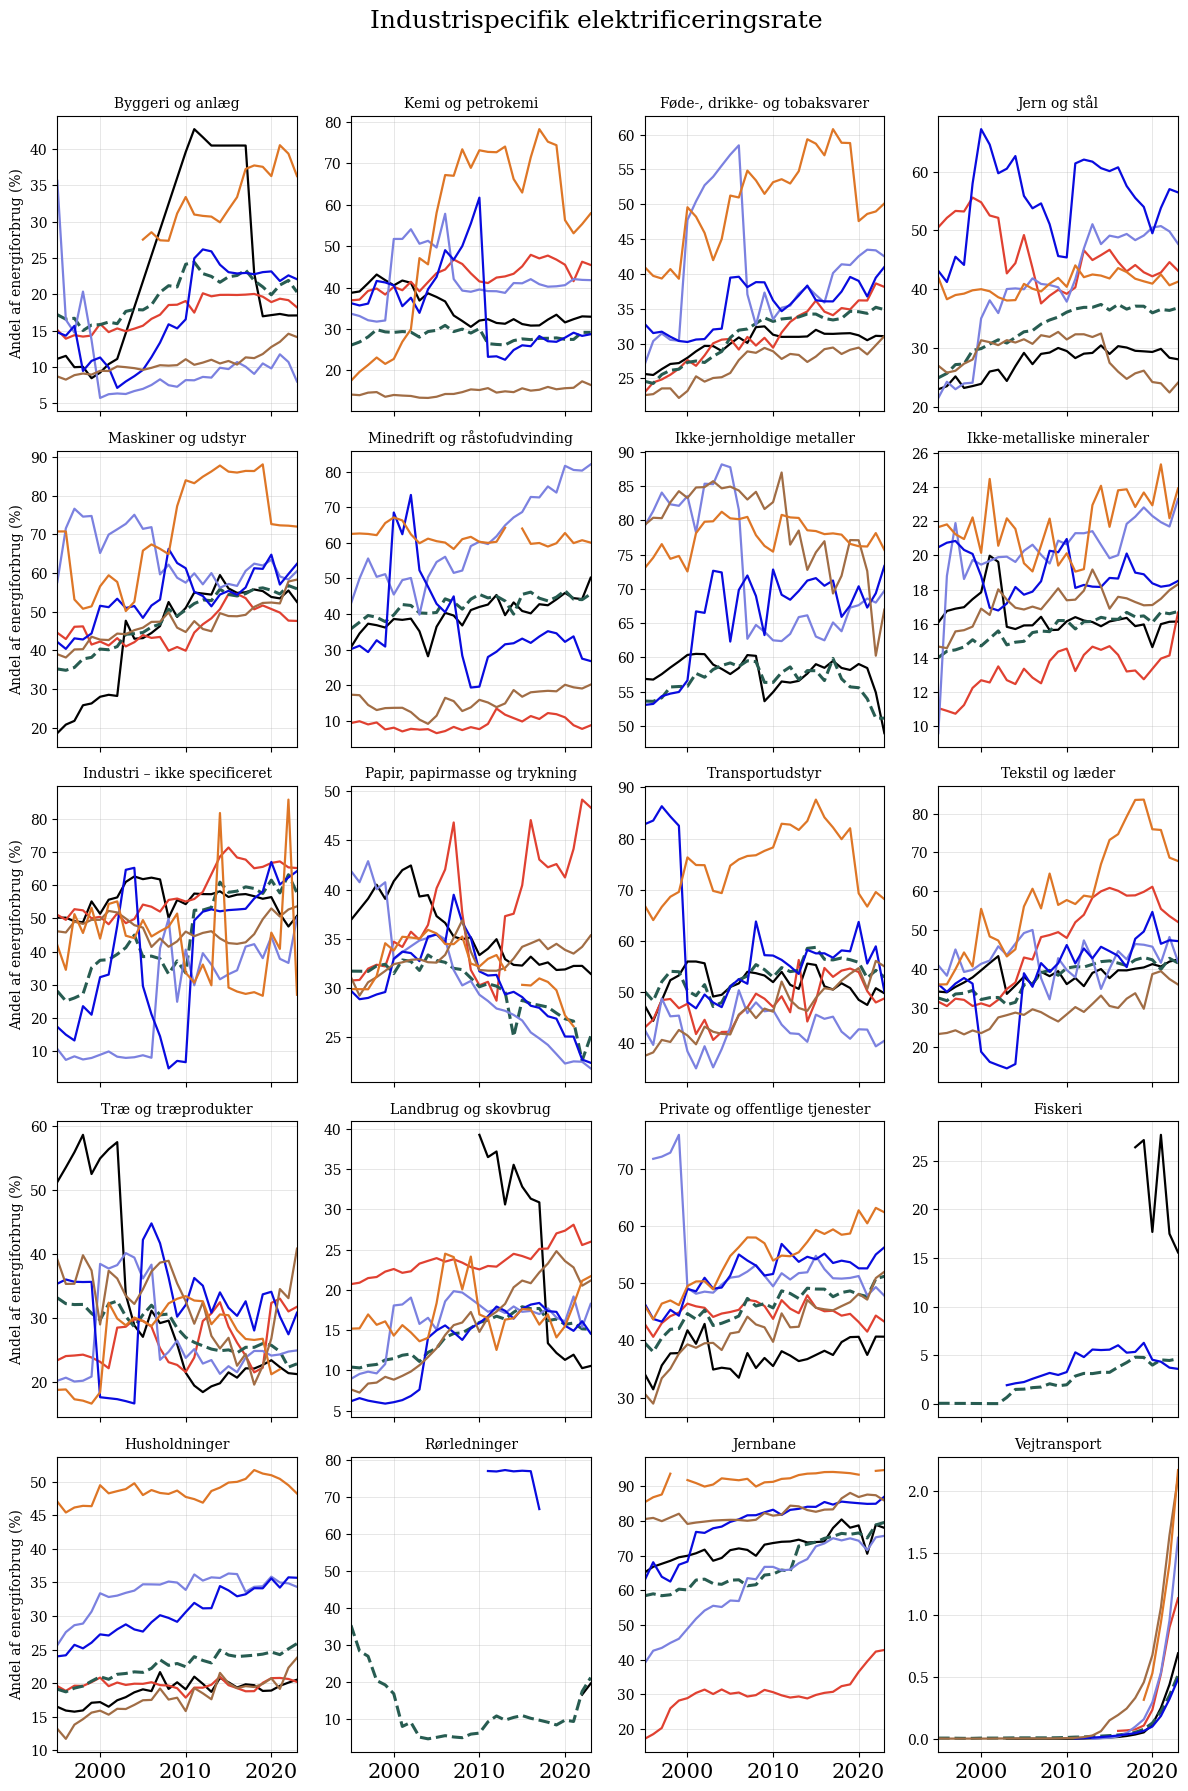

In [8]:
# 4. delsektorrate
df_s = pd.read_parquet("0_intermediate/df_s.parquet")

DROP_SECTORS = ['FC_TRA_DAVI_E', 'FC_TRA_DNAVI_E', 'FC_TRA_NSP_E', 'FC_OTH_NSP_E']
GEO_SUB = var_groups.countries

sub_data = df_s[df_s["geo"].isin(GEO_SUB) & ~df_s["nrg_bal"].isin(DROP_SECTORS)]
sectors = list(sub_data.nrg_bal.unique())

NCOLS = 4
NROWS = -(-len(sectors) // NCOLS)

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(12, 3.5 * NROWS), sharex=True, squeeze=False)
axes_flat = axes.flatten()

for i, (ax, nrg) in enumerate(zip(axes_flat, sectors)):
    sub = sub_data[sub_data["nrg_bal"] == nrg]
    for geo, grp in sub.groupby("geo"):
        grp = grp.sort_values("year").copy()
        grp.loc[(grp["value"] <= 0) | (grp["value"] > 95), "value"] = np.nan
        ax.plot(grp["year"], grp["value"],
                ls=STYLE[geo], color=PALETTE[geo], lw=LW[geo], label=geo)
    style_ax(ax, sub_data["year"], step=10)
    ax.set_title(var_groups.labels[nrg], fontsize=10)
    ax.tick_params(axis='y', labelsize=10)
    if i % NCOLS == 0:
        ax.set_ylabel("Andel af energiforbrug (%)", fontsize=10)

for ax in axes_flat[len(sectors):]:
    ax.axis("off")

plt.suptitle('Industrispecifik elektrificeringsrate', y=1.02)
plt.tight_layout()
plt.show()